In [45]:
# # Simple distance calculation using numpy
# import numpy as np

# penguin_a = np.array([40.0, 20.0])
# penguin_b = np.array([45.0, 15.0])

# distance = np.sqrt(np.sum((penguin_a - penguin_b) ** 2)) # Euclidean distance

# print(distance)

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [47]:
penguins = sns.load_dataset("penguins")
print(penguins.head())
print("\nDataset shape:", penguins.shape)
print("\nMissing values:\n", penguins.isnull().sum())
print("\nClass distribution:\n", penguins['species'].value_counts())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Dataset shape: (344, 7)

Missing values:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Class distribution:
 species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [48]:
# Relation between island and species
# sns.countplot(data=penguins, x="island", hue="species")
# plt.show()

In [49]:
feature_columns = [
    'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'
]

target_column = 'species'

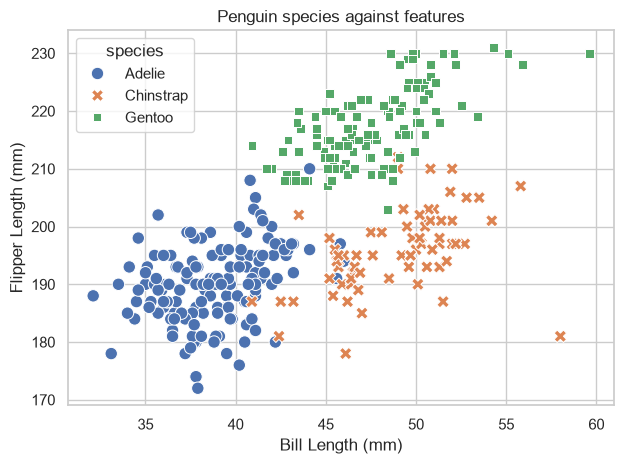

In [50]:
sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    style='species',
    s=80 # Size of points
)

plt.title("Penguin species against features")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.tight_layout()
plt.show()

In [51]:
data = penguins[feature_columns + [target_column]].dropna().copy()
print("Original data shape:", penguins.shape)
print("Data shape after dropping missing values:", data.shape)

Original data shape: (344, 7)
Data shape after dropping missing values: (342, 5)


In [52]:
X = data[feature_columns].to_numpy()
y = data[target_column].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (342, 4)
y shape: (342,)


In [53]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    # create a random-number generator from numpy
    rng = np.random.default_rng(seed=random_state)

    # Generate indices for all rows
    indices = np.arange(X.shape[0])

    # Randomly shuffle the indices
    rng.shuffle(indices)

    # Calculate the nuymber of test observations
    n_test = int(X.shape[0] * test_size)

    # Select the test and train indices
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # Split the dataset
    X_train = X[train_indices]
    y_train = y[train_indices]
    X_test = X[test_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

In [54]:
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (274, 4) (274,)
Test set shape: (68, 4) (68,)


In [55]:
print("\nTraining set class distribution:\n", pd.Series(y_train).value_counts())
print("\nTest set class distribution:\n", pd.Series(y_test).value_counts())


Training set class distribution:
 Adelie       120
Gentoo       101
Chinstrap     53
Name: count, dtype: int64

Test set class distribution:
 Adelie       31
Gentoo       22
Chinstrap    15
Name: count, dtype: int64


In [56]:
def fit_standerdizer(X_train):
    # Calculate the mean and standard deviation for each feature
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    return mean, std

def transform_standerdizer(X, mean, std):
    # Standardize the dataset
    X_standardized = (X - mean) / std
    return X_standardized

In [57]:
train_mean, train_std = fit_standerdizer(X_train)
X_train_standardized = transform_standerdizer(X_train, train_mean, train_std)
X_test_standardized = transform_standerdizer(X_test, train_mean, train_std)

print("Training features mean after standardization:", np.mean(X_train_standardized, axis=0))
print("Training features standard deviation after standardization:", np.std(X_train_standardized, axis=0))

Training features mean after standardization: [-6.84488962e-15 -5.03895384e-15 -3.23494273e-16 -8.40771086e-17]
Training features standard deviation after standardization: [1. 1. 1. 1.]


In [58]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [59]:
def predict_one(X_train, y_train, new_point, k=5):
    distances = []
    # Calculate the distance of every point from new point
    for training_point in X_train:
        distance = euclidean_distance(training_point, new_point)
        distances.append(distance)

    distances = np.array(distances)
    # sort and take index of k nearest points
    k_nearest_indices = np.argsort(distances)[:k]

    # Get the labels of the k nearest points
    k_nearest_labels = y_train[k_nearest_indices]

    labels, counts = np.unique(k_nearest_labels, return_counts=True)
    predicted_label = labels[np.argmax(counts)]

    return predicted_label

In [60]:
first_prediction = predict_one(
    X_train_standardized,
    y_train,
    X_test_standardized[0],
    k=5
)

print("Predicted label for the first test point:", first_prediction)
print("Actual label for the first test point:", y_test[0])

Predicted label for the first test point: Adelie
Actual label for the first test point: Adelie


In [61]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        prediction = predict_one(X_train, y_train, test_point, k)
        predictions.append(prediction)
    return np.array(predictions)

In [62]:
y_pred = knn_predict(X_train_standardized, y_train, X_test_standardized, k=5)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(15))

       Actual Predicted
0      Adelie    Adelie
1      Adelie    Adelie
2      Adelie    Adelie
3      Adelie    Adelie
4      Gentoo    Gentoo
5      Adelie    Adelie
6      Adelie    Adelie
7      Adelie    Adelie
8      Gentoo    Gentoo
9   Chinstrap    Adelie
10     Gentoo    Gentoo
11     Gentoo    Gentoo
12     Gentoo    Gentoo
13     Gentoo    Gentoo
14     Gentoo    Gentoo


In [64]:
def accuracy_score_manually(y_true, y_pred):
    correct_predictions = np.sum(y_true == y_pred)
    accuracy = correct_predictions / len(y_true)
    return accuracy

accuracy = accuracy_score_manually(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy: 0.9705882352941176
Accuracy in percentage: 97.05882352941177 %
